In [14]:
import sys
sys.path.append("/export/share/peters57dm/Verbund/deepsync/experiments")
from sklearn.metrics import pairwise_distances
import os
import numpy as np
from sklearn.neighbors import NearestNeighbors
from helper.plots import (plot_2d_dataset)
from helper.deep import (detect_device, load_pretrained_model, encode_batchwise, get_train_and_testloader)
from helper.datasets import (load_example, load_runEx, load_mnist, load_coil20, load_pendigits,load_optdigits, load_data, load_letterrecognition, load_gaussian_blobs, load_example, load_usps, load_htru, load_har,load_mice, 
    load_synth_high, load_synth_low, load_fmnist, load_cifar10, load_cifar100, load_coil20, load_coil100,load_weizmann)
from clustpy.deep.neural_networks import FeedforwardAutoencoder

In [15]:
# precomputes the k-th nearest neighbor distance (core_dist / kappa) and reuses this within every T% nearest neighbor subset
def find_local_core_points_same(data, k, percent):
    n = data.shape[0]
    subset = int(np.floor(n * percent))

    p_dist = pairwise_distances(data, metric="euclidean")
    core_dists = np.partition(p_dist, k - 1, axis=0)[k - 1]

    nn = np.argpartition(p_dist, subset, axis=1)[:, :subset]
    # nn_mask = np.tile(np.arange(n).reshape(-1, 1), (1, subset))
    # nn = nn[nn != nn_mask].reshape(n, subset - 1)
    refined_medians = np.median(core_dists[nn], axis=1)
    med_th = np.median(refined_medians)

    vector_mask = core_dists < refined_medians
    core_points_mask = np.outer(vector_mask, vector_mask).astype(int)
    return core_points_mask, med_th


# recompute the k-th nearest neighbor distance (core_dist / kappa) within every T% nearest neighbor subset and only computes k-th nearest neighbor distance on this subset
def find_local_core_points_adaptive(data, k, percent):
    n = data.shape[0]
    subset = int(np.floor(n * percent))

    p_dist = pairwise_distances(data, metric="euclidean")
    core_dists = np.partition(p_dist, k - 1, axis=0)[k - 1]

    nn = np.argpartition(p_dist, subset, axis=1)[:, :subset]
    # nn_mask = np.tile(np.arange(n).reshape(-1, 1), (1, subset))
    # nn = nn[nn != nn_mask].reshape(n, subset - 1)

    refined_medians = np.empty((n))
    for i in range(n):
        p_dist_neighbors = p_dist[np.ix_(nn[i], nn[i])]
        core_dists_neighbors = np.partition(p_dist_neighbors, k - 1, axis=0)[k - 1]
        refined_medians[i] = np.median(core_dists_neighbors)

    vector_mask = core_dists < refined_medians
    core_points_mask = np.outer(vector_mask, vector_mask).astype(int)
    return core_points_mask, refined_medians

# Original definition
def find_local_core_points_fast(data, k, percent):
    n = data.shape[0]
    subset = int(np.floor(n * percent))

    knn = NearestNeighbors(n_neighbors=subset, metric="euclidean").fit(data)
    distances, indices = knn.kneighbors(data)
    
    # Compute k-nearest neighbors within each subset
    refined_medians = np.zeros(n)
    for j in range(n):
        j_neighbors = data[indices[j], :]
        knn_j = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(j_neighbors)
        distances_j, _ = knn_j.kneighbors(j_neighbors)
        refined_medians[j] = np.median(distances_j[:, k-1])
    
    furthest_neighbor_points_distances = distances[:, k-1]
    vector_mask = furthest_neighbor_points_distances < refined_medians
    
    core_points_mask = np.outer(vector_mask, vector_mask).astype(int)
    core_threshold = np.median(refined_medians)
    
    return core_points_mask, core_threshold

In [16]:
data, labels, data_name = load_data(load_letterrecognition)

In [17]:
data.shape

torch.Size([20000, 16])

In [ ]:
#import torch
#data = torch.Tensor(data)

In [19]:
type(data)

torch.Tensor

In [20]:
gt_n_clusters = len(np.unique(labels))
print(gt_n_clusters)

26


In [21]:
device = detect_device()
device

device(type='cuda')

In [22]:
ae_layers = [256,128,64] #add correct dimensions
#ae_layers = [500,2000,2000]
embedded_space_dim = min(10,data.shape[1])
model = FeedforwardAutoencoder(
                    layers=[data.shape[1],
                        ae_layers[0], ae_layers[1], ae_layers[2], 
                        embedded_space_dim]
                    ).to(device)
#pretrained_model_path = "mse_pretrained_models256-128-64"
pretrained_model_path = "version-2_mse_pretrained_models256-128-64"
_mpath = os.path.join(pretrained_model_path, f"pretrained_{data_name}.pth")
model = load_pretrained_model(model, _mpath, device)

/export/share/peters57dm/Verbund/deepsync/experiments/helper/deep.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pretrained_model_path, map_lo

FileNotFoundError: [Errno 2] No such file or directory: 'version-2_mse_pretrained_models256-128-64/pretrained_letterrecognition.pth'

In [43]:
k=25
t=0.1

In [44]:
train_loader, test_loader = get_train_and_testloader(data,labels, batch_size=256)

In [45]:
embedded_data, embedded_labels = encode_batchwise(test_loader, model, device)


In [51]:
km_all = KMeans(n_clusters=gt_n_clusters, init="k-means++",n_init=10, random_state=7)
km_all.fit(embedded_data)
#plot_2d_kmeans_result(embedded_data, gt_labels, km.labels_, km.cluster_centers_, pairplot=False)
print("ARI",ARI(labels, km_all.labels_))
print("AMI",AMI(labels, km_all.labels_))
print("NMI",NMI(labels, km_all.labels_))


ARI 0.6420703127583139
AMI 0.7203765288983993
NMI 0.7204472635049699


In [46]:
mask_same_comment, th_same_comment = find_local_core_points_same(embedded_data, k, t)

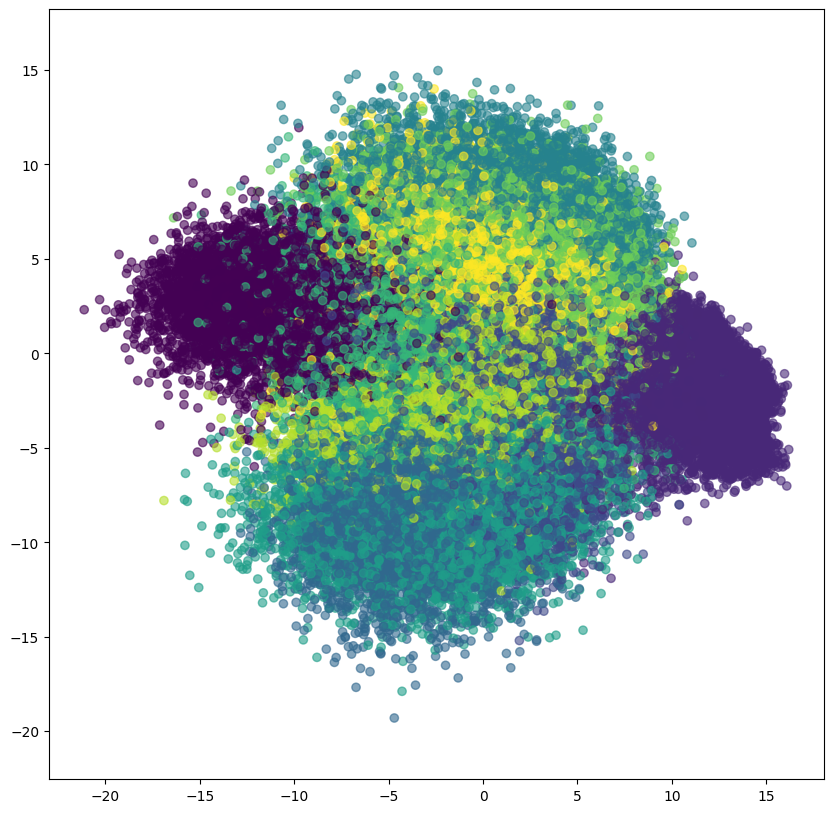

In [48]:
plot_2d_dataset(embedded_data, labels, core_points_mask=None)

In [16]:
core_points = embedded_data[np.where(np.diag(mask_same_comment) == 1)[0]]
core_point_labels = embedded_labels[np.where(np.diag(mask_same_comment) == 1)[0]]

In [17]:
core_points.shape

(474, 10)

In [18]:
n_clusters = len(np.unique(core_point_labels))
print(n_clusters)
print(gt_n_clusters)

16
20


In [145]:
#plot_2d_dataset(core_points, core_point_labels)

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import adjusted_rand_score as ARI 
from sklearn.metrics import adjusted_mutual_info_score as AMI

In [ ]:
km = KMeans(n_clusters=n_clusters, init="k-means++",n_init=10, random_state=7)
km.fit(core_points)
#plot_2d_kmeans_result(embedded_data, gt_labels, km.labels_, km.cluster_centers_, pairplot=False)
print("ARI",ARI(core_point_labels, km.labels_))
print("AMI",AMI(core_point_labels, km.labels_))
#print("NMI",NMI(core_point_labels, km.labels_))

In [148]:
# SHiP

In [20]:
import SHiP
from SHiP import SHiP

In [28]:
ship = SHiP(data=embedded_data, treeType="DCTree", config = {"k": 20})
labels_ship = ship.fit_predict(power=2, partitioningMethod="k")

In [29]:
ship_all_n_clusters = len(np.unique(labels_ship))
print(ship_all_n_clusters)


20


In [30]:
print("ARI",ARI(labels, labels_ship))
print("AMI",AMI(labels, labels_ship))
print("NMI",NMI(labels, labels_ship))

ARI 0.7647384043741408
AMI 0.8776326438228819
NMI 0.8830802499940725


In [25]:
ship = SHiP(data=core_points, treeType="DCTree", config = {"k": 20})
labels_ship_core = ship.fit_predict(power=2, partitioningMethod="k")

In [26]:
ship_core_n_clusters = len(np.unique(labels_ship_core))
print(ship_core_n_clusters)


20


In [27]:
print("ARI",ARI(core_point_labels, labels_ship_core))
print("AMI",AMI(core_point_labels, labels_ship_core))
print("NMI",NMI(core_point_labels, labels_ship_core))

ARI 0.9711125107240337
AMI 0.9694810138043215
NMI 0.9726291907752604


In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram,fcluster

1.5102472
Class distribution:
 {np.int32(1): np.int64(280), np.int32(2): np.int64(1937)}
Number of classes:
 2
ARI_raw 0.06321732333876738
AMI_raw 0.2837725260010777


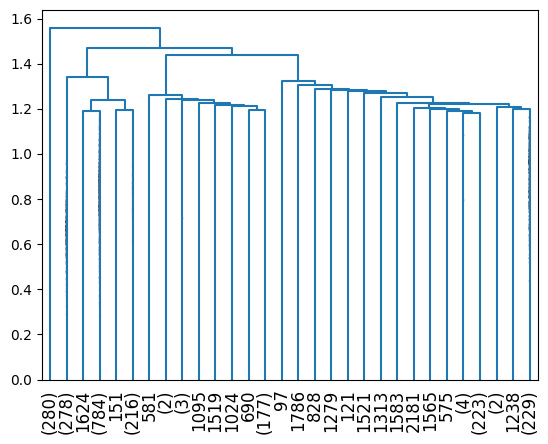

In [246]:
link = linkage(core_points, method='single', metric='euclidean', optimal_ordering=False)
dn = dendrogram(link,
    p=30,
    truncate_mode='lastp',
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True)
max_d = th_same_comment #doesn't work as general setting, don't know yet, what will
#max_d = 0.1
print(max_d)
link_labels = fcluster(link, max_d, criterion='distance')
link_n_clusters = len(np.unique(link_labels))

gt_uniques = np.unique(link_labels, return_counts=True)
print("Class distribution:\n", dict(zip(gt_uniques[0], gt_uniques[1])))
print("Number of classes:\n", link_n_clusters)

print("ARI_raw",ARI(core_point_labels, link_labels))
print("AMI_raw",AMI(core_point_labels, link_labels))


In [217]:
min_points = 25
liste = np.unique(link_labels)[gt_uniques[1] < min_points]
r = liste[0]
assign_points = core_points[link_labels == r]
#print(assign_points)
ids_assign_points = np.where(link_labels == r)[0]
#print(ids_assign_points)
for l in range(1,len(liste)):
    assign_current_points = core_points[link_labels == liste[l]]
    temp_ids = np.where(link_labels == liste[l])[0]
    assign_points = np.concatenate((assign_points, assign_current_points),axis = 0)
    ids_assign_points = np.concatenate((ids_assign_points,temp_ids),axis = 0)


In [218]:
print(assign_points.shape)
print(ids_assign_points.shape)

(59, 10)
(59,)


In [219]:
liste_true = np.unique(link_labels)[gt_uniques[1] >= min_points]
centres = np.array([np.mean(core_points[link_labels == liste_true[0]],0)])
print(centres)
for l in range(1,len(liste_true)):
    current_centre = np.array([np.mean(core_points[link_labels == liste_true[l]],0)])
    centres = np.concatenate((centres, current_centre),axis = 0)

[[-0.98828    -1.1602572  -0.46516433 -1.5630618   0.22967929  1.0467125
  -1.7106355   0.89292383 -0.34285212 -1.0860703 ]]


In [220]:
from scipy.spatial.distance import cdist

In [221]:
distances_2_centres = cdist(assign_points, centres)

In [222]:
min_dist = np.argmin(distances_2_centres,1)
print(min_dist)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 8 8 8 6 6 8
 1 2 8 8 2 8 8 2 2 2 2 2 2 2 2 2 2 8 8 2 2 0]


In [225]:
new_link_labels = link_labels.copy()

In [226]:
new_link_labels[ids_assign_points] = liste_true[min_dist]

In [227]:
print(liste_true)
print(np.unique(new_link_labels))


[ 2 15 17 18 21 22 23 24 25]
[ 2 15 17 18 21 22 23 24 25]


In [228]:
print("ARI_new",ARI(core_point_labels, new_link_labels))
print("AMI_new",AMI(core_point_labels, new_link_labels))


ARI_new 0.7934990815766568
AMI_new 0.8911402970946836


# Example

In [9]:
data_ex, labels_ex, _ = load_data(load_example)

In [23]:
mask_original, _ = find_local_core_points_fast(data_ex, k, t)

In [18]:
mask_same_comment, _ = find_local_core_points_same(data_ex, k, t)

In [25]:
mask_adaptive_comment, _ = find_local_core_points_adaptive(data_ex, k, t)

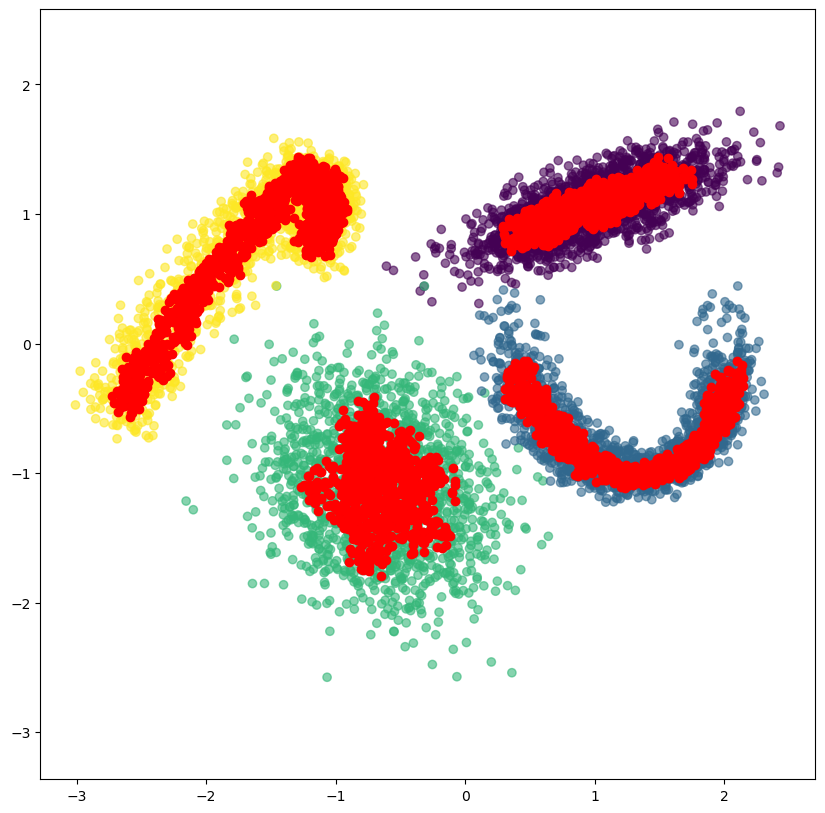

In [26]:
plot_2d_dataset(data_ex, labels_ex, core_points_mask=mask_original)

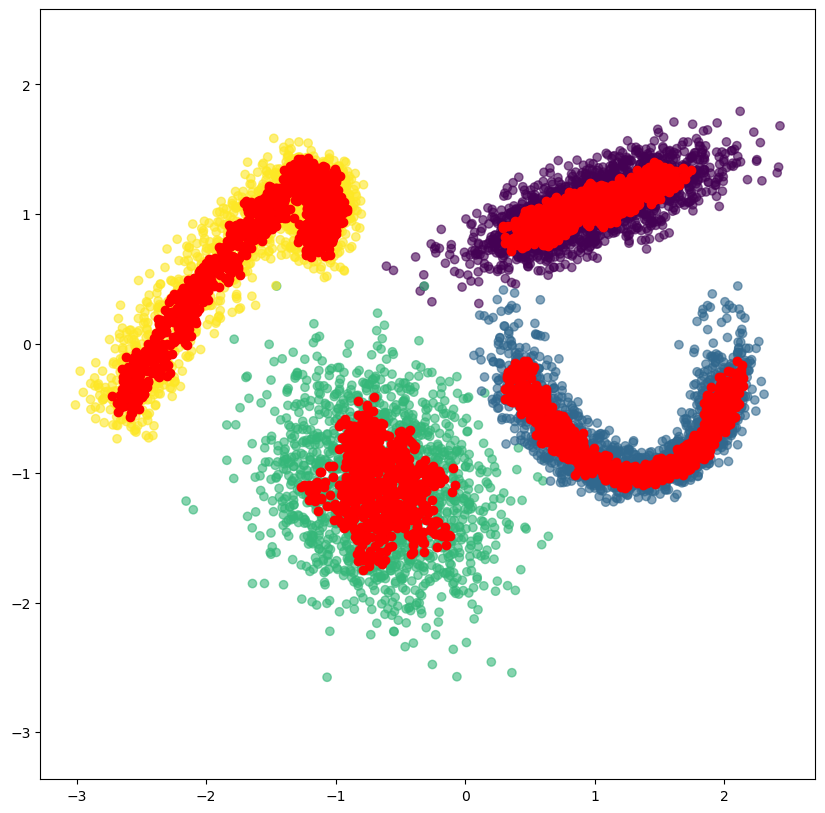

In [27]:
plot_2d_dataset(data_ex, labels_ex, core_points_mask=mask_same_comment)

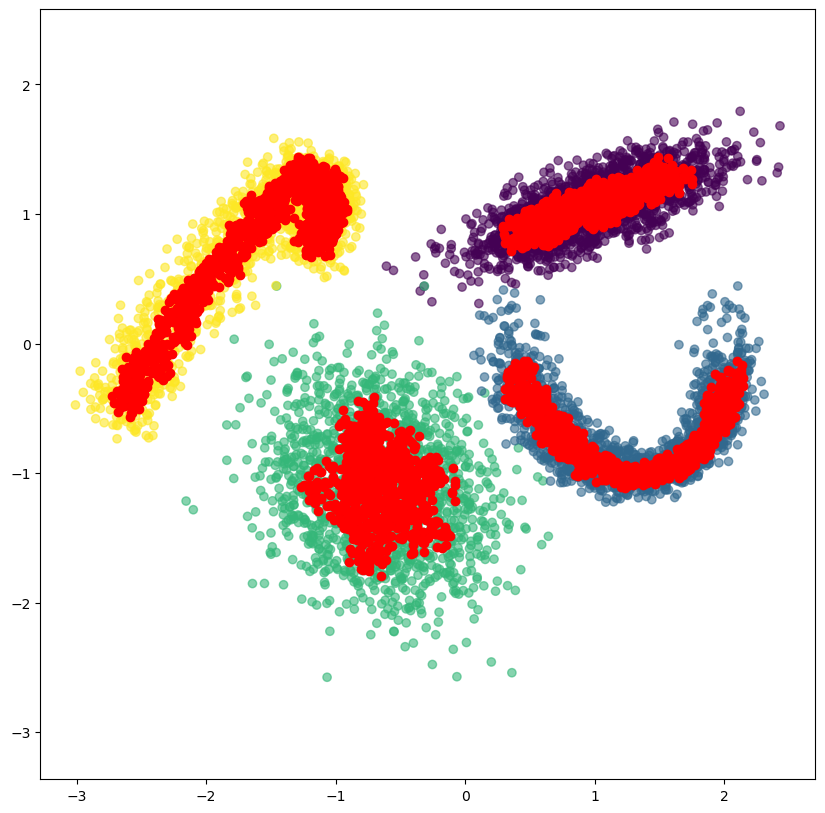

In [28]:
plot_2d_dataset(data_ex, labels_ex, core_points_mask=mask_adaptive_comment)

# include , exclude the point

In [6]:
def find_local_core_points_same(data, k, percent):
    n = data.shape[0]
    subset = int(np.floor(n * percent))

    p_dist = pairwise_distances(data, metric="euclidean")
    core_dists = np.partition(p_dist, k - 1, axis=0)[k - 1]

    nn = np.argpartition(p_dist, subset, axis=1)[:, :subset]
    nn_mask = np.tile(np.arange(n).reshape(-1, 1), (1, subset))
    nn = nn[nn != nn_mask].reshape(n, subset - 1)
    refined_medians = np.median(core_dists[nn], axis=1)
    med_th = np.median(refined_medians)

    vector_mask = core_dists < refined_medians
    core_points_mask = np.outer(vector_mask, vector_mask).astype(int)
    return core_points_mask, med_th

In [24]:
mask_same, th_same = find_local_core_points_same(data, k, t)

/export/share/peters57dm/Verbund/deepsync/helper.py:399: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647175880/work/torch/csrc/utils/tensor_new.cpp:278.)
  ax.scatter(data[np.where(np.diag(core_points_mask)==1),0],data[np.where(np.diag(core_points_mask)==1),1],c = 'r')


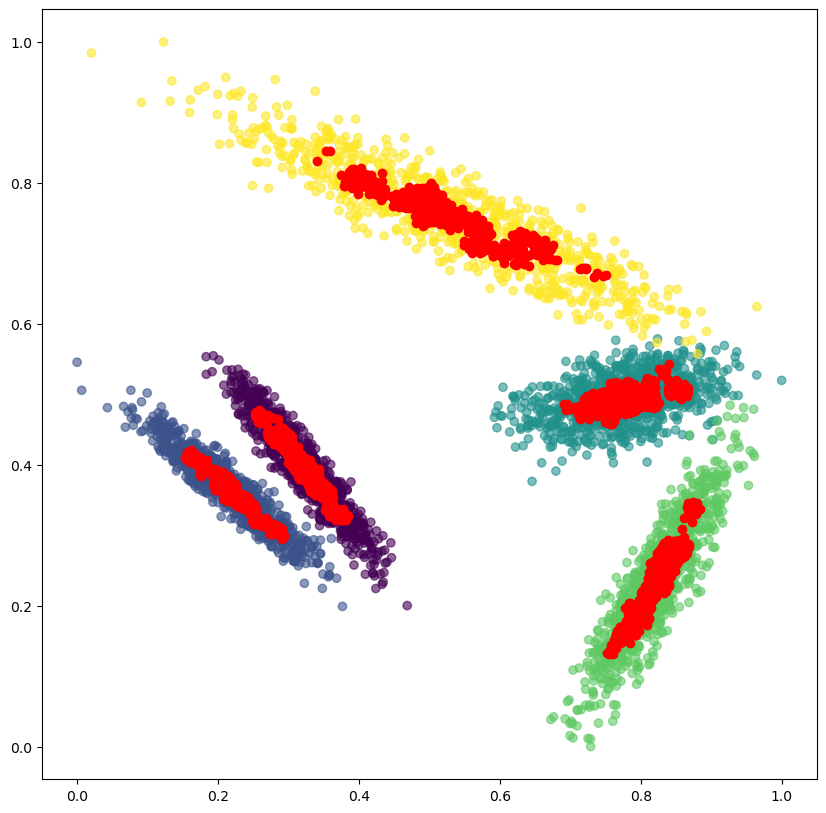

In [8]:
plot_2d_dataset(data, labels, core_points_mask=mask_same)

In [19]:
mask_same, th_same = find_local_core_points_same(data_ex, k, t)

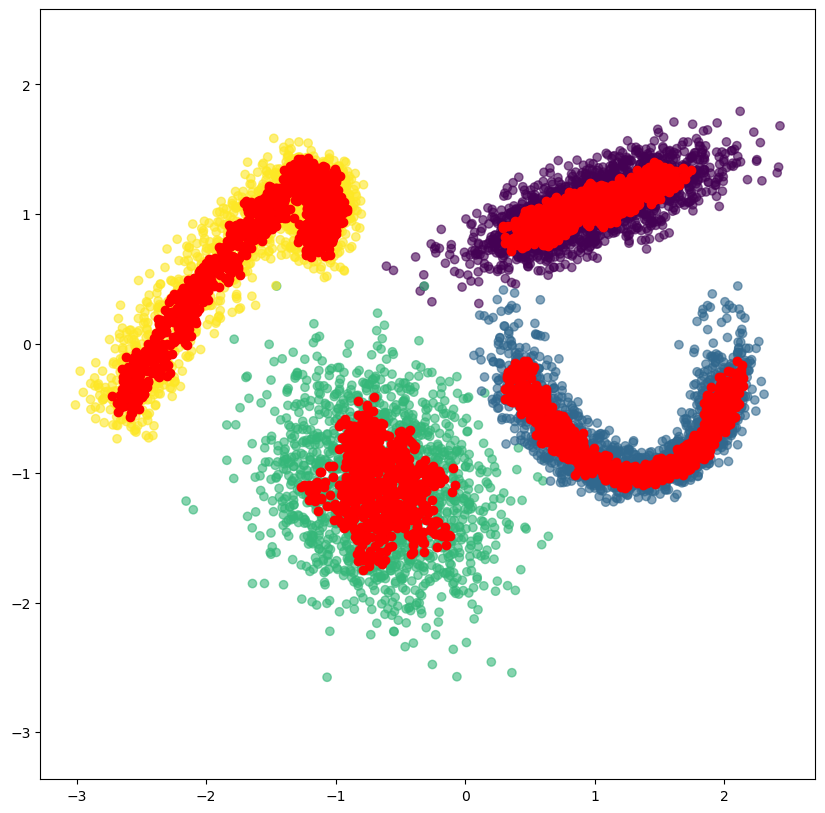

In [12]:
plot_2d_dataset(data_ex, labels_ex, core_points_mask=mask_same)

In [26]:
np.sum(mask_same)

3763600

In [27]:
np.sum(mask_same_comment)

3763600

In [28]:
np.all(mask_same == mask_same_comment)

True